# lab 6

In [34]:
import matplotlib.pyplot as plt
import scipy
import numpy as np
from numpy.linalg import inv

A = [
  [39, 2, -4, 8, -4],
  [-10, 48, 0, -6, 7],
  [-9, 9, 45, -6, 3],
  [-10, 8, 0, 31, -5],
  [-6, 9, -3, -2, 48]
]

b = [41, 39, 42, 24, 46]
exact = [1, 1, 1, 1, 1]

print(A)
print(b)
print(exact)

[[39, 2, -4, 8, -4], [-10, 48, 0, -6, 7], [-9, 9, 45, -6, 3], [-10, 8, 0, 31, -5], [-6, 9, -3, -2, 48]]
[41, 39, 42, 24, 46]
[1, 1, 1, 1, 1]


In [35]:
def proizsvv(v1, v2):
    return sum(v1[i] * v2[i] for i in range(len(v1)))

def mv(A, v):
    n = len(A)
    result = [0.0] * n
    for i in range(n):
        for j in range(n):
            result[i] += A[i][j] * v[j]
    return result

def razn(v1, v2):
    return [v1[i] - v2[i] for i in range(len(v1))]

def summ(v1, v2):
    return [v1[i] + v2[i] for i in range(len(v1))]

def normv(v):
    return sum(x*x for x in v) ** 0.5

def scalyar(s, v):
    return [s * x for x in v]

def mm(A, B):
    m = len(A)
    n = len(A[0])
    n2 = len(B)
    m2 = len(B[0])

    result = [[0] * n2 for _ in range(m)]

    for i in range(m):
        for j in range(n2):
            for k in range(n):
                result[i][j] += A[i][k] * B[k][j]
    return result

In [40]:
def minn(A, b, maxi=1000, epsilon=1e-12):
    n = len(b) 
    x = [0.0] * n
    t = []

    for k in range(maxi):
        r = razn(b, mv(A, x))
        nevyazka = normv(r)

        # if nevyazka < epsilon:
        #     break

        Ar = mv(A, r)
        chis = proizsvv(r, Ar)
        znam = proizsvv(Ar, Ar)

        if abs(znam) < 1e-15:
            break

        tau = chis/znam
        t.append(tau)
        x0 = x
        x = summ(x, scalyar(tau, r))
        if normv(razn(x,x0)) < epsilon:
            break

        print(f"{k+1}\t{tau}\t{nevyazka}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, [1, 1, 1, 1, 1]))

    print(f"Otvet: {[f'{val:.6f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(t)}")

    return x, t
minn(A, b)

1	0.023667025634998035	87.50999942863673
2	0.02104267014038389	15.887794360126573
3	0.022852993644232905	7.504709612092996
4	0.025513657520678603	1.4907267407487392
5	0.018918095510965578	0.3016138904351877
6	0.026796410881408973	0.15052883253622826
7	0.026274266183063725	0.028270237020975676
8	0.025454937897261762	0.006158117227708482
9	0.02193015191238838	0.0025989569536759567
10	0.025384276531269255	0.0004920377476640373
11	0.018185964731287283	0.0001034603241794686
12	0.02775934810836447	5.003886341420258e-05
13	0.025321563733128976	1.0353982779635474e-05
14	0.02783709393091649	2.542632383814948e-06
15	0.024880610432027304	6.913835266509471e-07
16	0.026646840906835955	1.4686010879981335e-07
17	0.028456422041236728	3.5065297773694534e-08
18	0.018991010972008535	9.435727211230613e-09
19	0.027203681727039974	3.2003218263555204e-09
Otvet: ['1.000000', '1.000000', '1.000000', '1.000000', '1.000000']
Norma: 7.72e-10
Pogreshnost: 2.12e-11
Iteratcii: 19


([1.000000000007138,
  0.9999999999935082,
  0.9999999999979224,
  0.9999999999814508,
  1.0000000000024907],
 [0.023667025634998035,
  0.02104267014038389,
  0.022852993644232905,
  0.025513657520678603,
  0.018918095510965578,
  0.026796410881408973,
  0.026274266183063725,
  0.025454937897261762,
  0.02193015191238838,
  0.025384276531269255,
  0.018185964731287283,
  0.02775934810836447,
  0.025321563733128976,
  0.02783709393091649,
  0.024880610432027304,
  0.026646840906835955,
  0.028456422041236728,
  0.018991010972008535,
  0.027203681727039974])

       1	0.02	8.75e+01
       2	0.02	1.62e+01
       3	0.02	8.20e+00
       4	0.03	1.44e+00
       5	0.03	3.02e-01
       6	0.02	1.52e-01
       7	0.03	3.17e-02
       8	0.03	8.30e-03
       9	0.03	1.70e-03
      10	0.02	8.91e-04
      11	0.03	1.56e-04
      12	0.02	3.48e-05
      13	0.02	1.64e-05
      14	0.03	2.85e-06
      15	0.02	7.68e-07
      16	0.03	2.76e-07
      17	0.03	5.58e-08
      18	0.03	1.20e-08
      19	0.02	6.96e-09
Otvet: ['1.00', '1.00', '1.00', '1.00', '1.00']
Norma: 1.10e-09
Pogreshnost: 2.91e-11
Iteratcii: 19


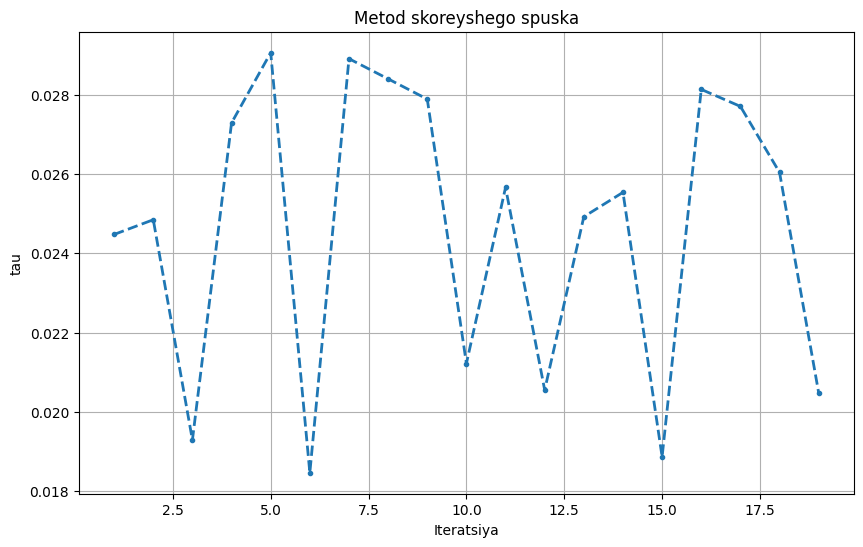


Pervye 10 znacheniya tau:
tau_1 = 2.45e-02
tau_2 = 2.48e-02
tau_3 = 1.93e-02
tau_4 = 2.73e-02
tau_5 = 2.91e-02
tau_6 = 1.85e-02
tau_7 = 2.89e-02
tau_8 = 2.84e-02
tau_9 = 2.79e-02
tau_10 = 2.12e-02


In [20]:
def spusk(A, b, maxi=1000, epsilon=1e-12):
    n = len(b)
    x = [0.0] * n
    t = []

    for k in range(maxi):
        r = razn(b, mv(A, x))
        nevyazka = normv(r)
        if nevyazka < epsilon:
            break

        Ar = mv(A, r)
        chis = proizsvv(r, r)
        znam = proizsvv(r, Ar)

        if abs(znam) < 1e-15:
            break

        tau = chis/znam
        t.append(tau)
        x = summ(x, scalyar(tau, r))

        print(f"{k+1:8d}\t{tau:.2f}\t{nevyazka:.2e}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, exact))

    print(f"Otvet: {[f'{val:.2f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(t)}")

    return x, t

solution, tau_history = spusk(A, b, maxi=1000)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(tau_history)+1), tau_history, '.--', linewidth=2, markersize=6)
plt.xlabel('Iteratsiya')
plt.ylabel('tau')
plt.title('Metod skoreyshego spuska')
plt.grid(True)
plt.show()

print("\nPervye 10 znacheniya tau:")
for i, tau in enumerate(tau_history[:10], 1):
    print(f"tau_{i} = {tau:.2e}")

(array([0.92063264, 0.88185675, 0.8895586 , 0.83494962, 0.93075706]), 50)
       1	0.0244737254	0.0340853894	8.75e+01
       2	0.0261933531	0.2091862523	1.62e+01
       3	0.0197142544	0.2443283942	7.39e+00
       4	0.0176762626	0.7882739249	3.65e+00
       5	0.0155683866	1.1079126494	3.24e+00
       6	0.0089042352	0.8392919975	3.41e+00
       7	0.0061441557	0.8294983235	3.13e+00
       8	0.0051217154	0.9951394647	2.85e+00
       9	0.0044969525	1.1810803890	2.84e+00
      10	0.0038016773	1.2572152181	3.09e+00
      11	0.0030598565	1.2152468538	3.46e+00
      12	0.0024235444	1.1291401971	3.82e+00
      13	0.0019503997	1.0550377617	4.06e+00
      14	0.0016188337	1.0107009048	4.17e+00
      15	0.0013878424	0.9944773664	4.19e+00
      16	0.0012229392	0.9993057208	4.18e+00
      17	0.0011000608	1.0176929393	4.17e+00
      18	0.0010033235	1.0428556062	4.21e+00
      19	0.0009224797	1.0690121313	4.30e+00
      20	0.0008511633	1.0916861097	4.45e+00
      21	0.0007857340	1.1079917800	4.65e+00
  

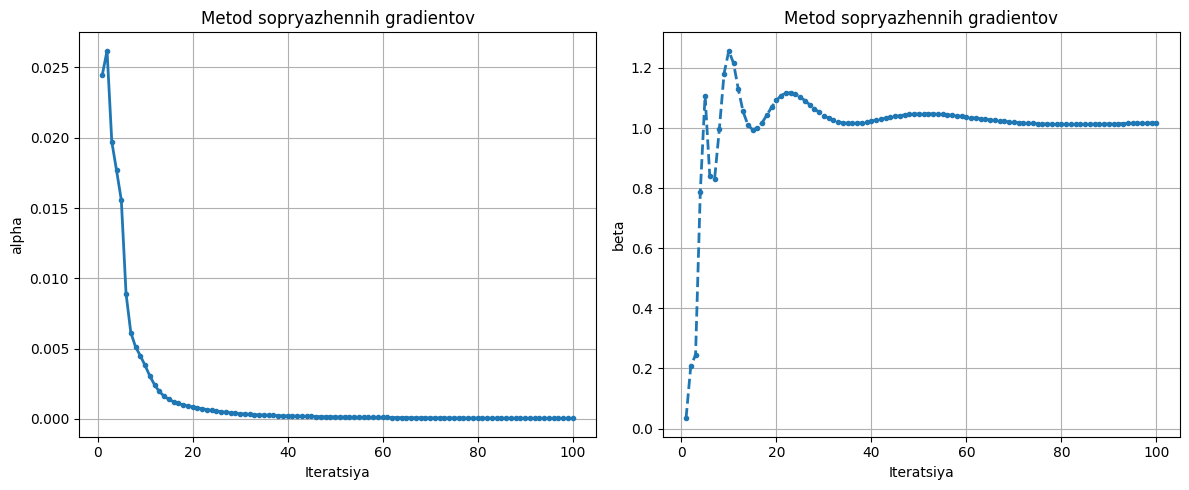


Pervye 10 znacheniy alpha i beta:
alpha_1 = 2.45e-02, beta_1 = 3.41e-02
alpha_2 = 2.62e-02, beta_2 = 2.09e-01
alpha_3 = 1.97e-02, beta_3 = 2.44e-01
alpha_4 = 1.77e-02, beta_4 = 7.88e-01
alpha_5 = 1.56e-02, beta_5 = 1.11e+00
alpha_6 = 8.90e-03, beta_6 = 8.39e-01
alpha_7 = 6.14e-03, beta_7 = 8.29e-01
alpha_8 = 5.12e-03, beta_8 = 9.95e-01
alpha_9 = 4.50e-03, beta_9 = 1.18e+00
alpha_10 = 3.80e-03, beta_10 = 1.26e+00


In [21]:
x = scipy.sparse.linalg.cg(np.asarray(A), np.asarray(b))
print(x)
def grad(A, b, maxi=1000, epsilon=1e-20):
    n = len(b)
    x = [0.0] * n
    aa = []
    bb = []

    r = razn(b, mv(A, x))
    p = r[:]

    for k in range(maxi):
        nevyazka = normv(r)

        if nevyazka < epsilon:
            break

        Ap = mv(A, p)
        chis_alpha = proizsvv(r, r)
        znam_alpha = proizsvv(Ap, p)
        alpha = chis_alpha / znam_alpha
        aa.append(alpha)
        
        x = summ(x, scalyar(alpha, p))

        r = razn(r, scalyar(alpha, Ap))

        chis_beta = proizsvv(r, r)
        znam_beta = chis_alpha

        if abs(znam_beta) < 1e-15:
            beta = 0.0
        else:
            beta = chis_beta / znam_beta

        bb.append(beta)
        p = summ(r, scalyar(beta, p))

        print(f"{k+1:8d}\t{alpha:.10f}\t{beta:.10f}\t{nevyazka:.2e}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, exact))

    print(f"Otvet: {[f'{val:.6f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(aa)}")

    return x, aa, bb

solution3, alpha3, beta3 = grad(A, b, maxi=100)


print(solution3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(range(1, len(alpha3)+1), alpha3, '.-', linewidth=2, markersize=6)
ax1.set_xlabel('Iteratsiya')
ax1.set_ylabel('alpha')
ax1.set_title('Metod sopryazhennih gradientov')
ax1.grid(True)

ax2.plot(range(1, len(beta3)+1), beta3, '.--', linewidth=2, markersize=6)
ax2.set_xlabel('Iteratsiya')
ax2.set_ylabel('beta')
ax2.set_title('Metod sopryazhennih gradientov')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nPervye 10 znacheniy alpha i beta:")
for i in range(min(10, len(alpha3))):
    print(f"alpha_{i+1} = {alpha3[i]:.2e}, beta_{i+1} = {beta3[i]:.2e}")

       1	0.8918638784	8.75e+01
       2	0.8136077483	3.16e+03
       3	0.7424267477	1.12e+05
       4	0.6890801624	3.95e+06
       5	0.6572686060	1.38e+08
       6	0.6425266301	4.83e+09
       7	0.6380056583	1.69e+11
       8	0.6384178160	5.92e+12
       9	0.6406700790	2.07e+14
      10	0.6432385156	7.28e+15
      11	0.6454924552	2.56e+17
      12	0.6472487293	8.98e+18
      13	0.6485230093	3.15e+20
      14	0.6494030792	1.11e+22
      15	0.6499893109	3.89e+23
      16	0.6503700147	1.36e+25
      17	0.6506139538	4.79e+26
      18	0.6507706568	1.68e+28
      19	0.6508737281	5.89e+29
      20	0.6509448111	2.06e+31
      21	0.6509971704	7.23e+32
      22	0.6510385342	2.53e+34
      23	0.6510731691	8.88e+35
      24	0.6511032986	3.11e+37
      25	0.6511300182	1.09e+39
      26	0.6511538510	3.82e+40
      27	0.6511750647	1.34e+42
      28	0.6511938361	4.68e+43
      29	0.6512103277	1.64e+45
      30	0.6512247143	5.75e+46
      31	0.6512371859	2.01e+48
      32	0.6512479416	7.05e+49
      33

C:\Users\mythy\AppData\Local\Temp\ipykernel_15320\3866821541.py:2: RuntimeWarning: overflow encountered in scalar add
  return sum(v1[i] * v2[i] for i in range(len(v1)))
C:\Users\mythy\AppData\Local\Temp\ipykernel_15320\572589432.py:30: RuntimeWarning: invalid value encountered in scalar divide
  tau = chis/znam


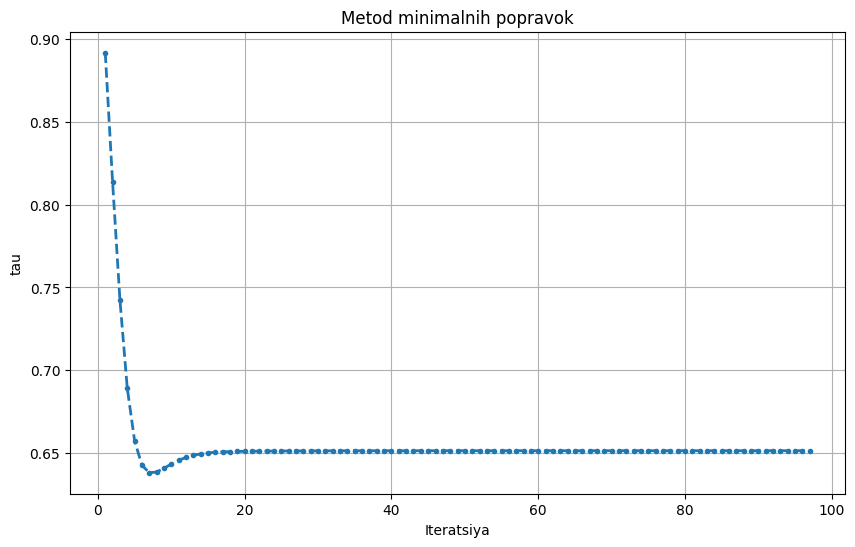


Pervye 10 znacheniy tau:
tau_1 = 8.92e-01
tau_2 = 8.14e-01
tau_3 = 7.42e-01
tau_4 = 6.89e-01
tau_5 = 6.57e-01
tau_6 = 6.43e-01
tau_7 = 6.38e-01
tau_8 = 6.38e-01
tau_9 = 6.41e-01
tau_10 = 6.43e-01


[np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan)]

In [41]:

B= [
    [39, 0, 0, 0, 0],
    [0, 39, 0, 0, 0],
    [0, 0, 33, 0, 0],
    [0, 0, 0, 43, 0],
    [0, 0, 0, 0, 38]
]


def minp(A,B, b, maxi=100, epsilon=1e-12):
    B_inv =  inv(B)
    n = len(b)
    x = [0.0] * n
    t = [] 

    for k in range(maxi):
        r = razn(b, mv(A, x))
        nevyazka = normv(r)

        if nevyazka < epsilon:
            break

        w = mv(B,  r)
        chis =proizsvv(mv(A, w),w)
        znam = proizsvv(mv(mm(B_inv,A), w), mv(A,w))

        if abs(znam) < 1e-15:
            break

        tau = chis/znam
        t.append(tau)
        x = summ(x, scalyar(tau, r))

        print(f"{k+1:8d}\t{tau:.10f}\t{nevyazka:.2e}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, exact))

    print(f"Otvet: {[f'{val:.6f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(t)}")

    return x, t

solution2, tau2 = minp(A, B, b, maxi=100)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(tau2)+1), tau2, '.--', linewidth=2, markersize=6)
plt.xlabel('Iteratsiya')
plt.ylabel('tau')
plt.title('Metod minimalnih popravok')
plt.grid(True)
plt.show()

print("\nPervye 10 znacheniy tau:")
for i, tau in enumerate(tau2[:10], 1):
    print(f"tau_{i} = {tau:.2e}")
solution2

# Laba 8

In [ ]:
def LU(A):
    n = len(A)
    L = [[0.0] * n for _ in range(n)]
    U = [[0.0] * n for _ in range(n)]
    for i in range(n):
        U[i][i] = 1.0

    for j in range(n):
        for i in range(j, n):
            s = 0.0
            for k in range(j):
                s += L[i][k] * U[k][j]
            L[i][j] = A[i][j] - s

        for k in range(j + 1, n):
            s = 0.0
            for m in range(j):
                s += L[j][m] * U[m][k]
            U[j][k] = (A[j][k] - s) / L[j][j]

    return L, U

def LyEqb(L, b):
    n = len(L)
    y = [0.0] * n
    for i in range(n):
        s = 0.0
        for j in range(i):
            s += L[i][j] * y[j]
        y[i] = (b[i] - s) / L[i][i]
    return y

def UxEqy(U, y):
    n = len(U)
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = 0.0
        for j in range(i + 1, n):
            s += U[i][j] * x[j]
        x[i] = y[i] - s
    return x

def LUsolv(A, b):
    L, U = LU(A)
    y = LyEqb(L, b)
    x = UxEqy(U, y)
    return x, L, U

def invmatrix(A):
    n = len(A)
    L, U = LU(A)
    inv = [[0.0] * n for _ in range(n)]

    for j in range(n):
        e = [0.0] * n
        e[j] = 1.0
        y = LyEqb(L, e)
        x = UxEqy(U, y)
        for i in range(n):
            inv[i][j] = x[i]
    return inv


def gauss_solve(A, b, pivot=True):
    """
    Метод Гаусса для Ax=b.
    pivot=True: выбор главного элемента по столбцу (частичный выбор),
    чтобы не делить на малые числа.
    """
    n = len(A)
    M = [A[i][:] + [b[i]] for i in range(n)] 

    # Прямой ходs
    for k in range(n):
        if pivot:
            # найти строку с максимальным |M[i][k]|
            best = max(range(k, n), key=lambda i: abs(M[i][k]))
            M[k], M[best] = M[best], M[k]

        if abs(M[k][k]) < 1e-12:
            raise ZeroDivisionError("Нулевой ведущий элемент в методе Гаусса.")

        for i in range(k + 1, n):
            factor = M[i][k] / M[k][k]
            for j in range(k, n + 1):
                M[i][j] -= factor * M[k][j]

    # Обратный ход
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = 0.0
        for j in range(i + 1, n):
            s += M[i][j] * x[j]
        x[i] = (M[i][n] - s) / M[i][i]

    return x


A = [
    [2, 10, -3, 6, -7],
    [3,  9, -4, 7, -8],
    [4, -8,  5, 6, -9],
    [5, -9, -6,-7, 10],
    [6, 10,  7, 8,-11],
]
b = [4, 5, 4, 23, 34]
ans = [5, 1, 2, 3, 4]

x, L, U = LUsolv(A, b)

print("x =", x)
print("x*=", ans)
print()

print(np.array(L))
print(np.array(U))

A_inv = invmatrix(A)
print(np.array(A_inv))

x2 = LUsolv(A, b)[0]
print(x2)
print(np.array(A_inv)@np.array(A))

A2 = [
    [2, -1, -1],
    [3,  4, -2],
    [3, -2,  4],
]
b2 = [4, 11, 11]

x2 = gauss_solve(A2, b2, pivot=True)
print("б) Решение 3x3 методом Гаусса:")
print("x =", x2)

x = [5.0, 1.0000000000000002, 1.999999999999999, 2.999999999999991, 3.999999999999993]
x*= [5, 1, 2, 3, 4]

[[  2.           0.           0.           0.           0.        ]
 [  3.          -6.           0.           0.           0.        ]
 [  4.         -28.           8.66666667   0.           0.        ]
 [  5.         -34.          -1.33333333 -10.15384615   0.        ]
 [  6.         -20.          14.33333333  -8.84615385   1.96969697]]
[[ 1.          5.         -1.5         3.         -3.5       ]
 [ 0.          1.         -0.08333333  0.33333333 -0.41666667]
 [ 0.          0.          1.          0.38461538 -0.76923077]
 [ 0.          0.          0.          1.         -1.21212121]
 [ 0.          0.          0.          0.          1.        ]]
[[ 0.24615385 -0.2         0.03461538  0.11538462  0.06538462]
 [ 0.30769231 -0.25       -0.01923077  0.01923077  0.01923077]
 [-1.03846154  0.75       -0.15384615 -0.09615385  0.15384615]
 [-8.15384615  6.75       -1.11538462 -0.63461

# Lab 10

In [ ]:
def r_prog(a, b, c, d):
    n = len(b)
    p = [0.0] * n
    q = [0.0] * n


    p[0] = -c[0] / b[0]
    q[0] = d[0] / b[0]
    
    for i in range(1, n):
        db = b[i] + a[i] * p[i - 1]
        p[i] = -c[i] / db if i < n - 1 else 0.0
        q[i] = (d[i] - a[i] * q[i - 1]) / db

    x = [0.0] * n
    x[n - 1] = q[n - 1]
    for i in range(n - 2, -1, -1):
        x[i] = p[i] * x[i + 1] + q[i]

    return x, p, q


def l_prog(a, b, c, d):
    """
    Левая прогонка (справа налево), без опоры на правую.

    Система: a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i], i=0..n-1
    где a[0]=0, c[n-1]=0.

    Строим представление: x[i] = r[i]*x[i-1] + s[i].
    1) "Прямой ход" справа налево: находим r[i], s[i]
    2) "Обратный ход" слева направо: восстанавливаем x[i]
    """
    n = len(b)
    if not (len(a) == len(c) == len(d) == n):
        raise ValueError("a, b, c, d должны быть одной длины")

    r = [0.0] * n
    s = [0.0] * n

    # Старт справа: (a_n x_{n-1} + b_n x_n = d_n) => x_n = (-a_n/b_n)*x_{n-1} + d_n/b_n
    r[n - 1] = -a[n - 1] / b[n - 1]
    s[n - 1] = d[n - 1] / b[n - 1]

    # Ход справа налево:
    # a_i x_{i-1} + b_i x_i + c_i x_{i+1} = d_i
    # подставляем x_{i+1} = r_{i+1} x_i + s_{i+1}:
    # a_i x_{i-1} + (b_i + c_i r_{i+1}) x_i = d_i - c_i s_{i+1}
    # => x_i = -(a_i)/(b_i + c_i r_{i+1}) * x_{i-1} + (d_i - c_i s_{i+1})/(b_i + c_i r_{i+1})
    for i in range(n - 2, -1, -1):
        denom = b[i] + c[i] * r[i + 1]
        if denom == 0:
            raise ZeroDivisionError(f"На шаге i={i} denom=0, левая прогонка невозможна")
        r[i] = -a[i] / denom
        s[i] = (d[i] - c[i] * s[i + 1]) / denom

    # Восстановление решения слева направо:
    # при i=0 (первое уравнение) a[0]=0 => r[0]=0, x0 = s0
    x = [0.0] * n
    x[0] = s[0]
    for i in range(1, n):
        x[i] = r[i] * x[i - 1] + s[i]

    return x



a = [0.0, 3.0, 1.0, 4.0, 1.0, -2.0]
b = [2.0, 6.0, -5.0, -7.0, 5.0, 7.0]
c = [-1.0, -2.0, 2.0, 1.0, 2.0, 0.0] 
d = [1.0, 9.0, 3.0, -6.0, 8.0, 5.0]

x_right, p, q = r_prog(a, b, c, d)
x_left = l_prog(a, b, c, d)


print("Правая прогонка  x =", x_right)
print("Левая прогонка   x =", x_left)

x = [1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
x

Правая прогонка  x = [1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
Левая прогонка   x = [1.0, 0.9999999999999999, -5.551115123125783e-17, 1.0, 1.0, 1.0]


[1.0, 1.0, 0.0, 1.0, 1.0, 1.0]

# lab 12

1.4289062499999998   7
1.4288700112158028   10
1.428870011214077   4
-2.0   1
-1.428870011209542   11
-2.0   1


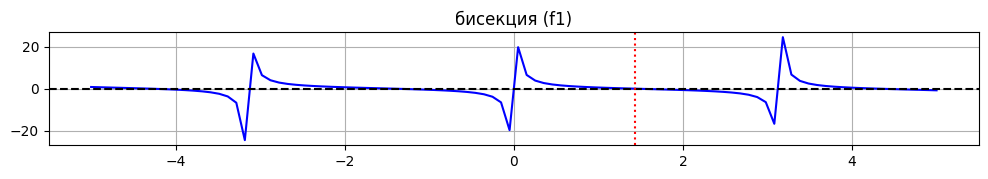

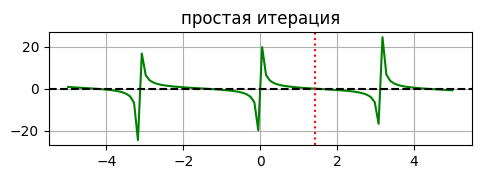

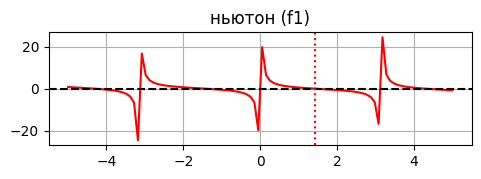

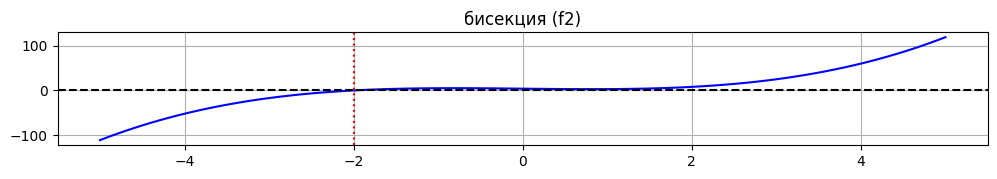

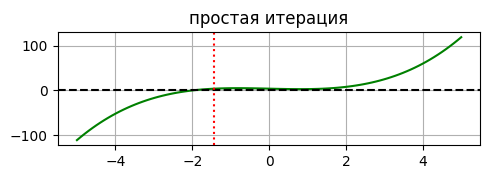

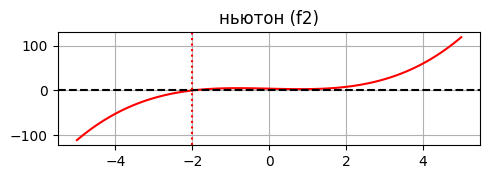

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f1(x):
    return np.cos(x)/np.sin(x) - x/10

def f1_proizv(x):
    return -1/(np.sin(x)*np.sin(x)) - 1/10

def f2(x):
    return x**3 - 2*x + 4

def f2_proizv(x):
    return 3*x**2 - 2


def bisection(f, a, b, eps=1e-4, max_iter=100):
    fa = f(a)
    fb = f(b)
    c = (a + b) / 2.0
    for k in range(max_iter):
        c = (a + b) / 2.0
        fc = f(c)

        if fa * fc > 0:
            a = c
            fa = fc
        else:
            b = c
            fb = fc

        if abs(fc) < eps or abs(b - a) < eps:
            return c, k + 1

    return c, max_iter


def phi(x: float) -> float:
    return np.atan(10.0 / x)

def dphi_abs(x: float) -> float:
    return 10.0 / (x * x + 100.0)


def iterat(f, f_proizv, a, b, eps=1e-10, max_iter=1000, grid_n=100000):
    """
    Оставил имя/сигнатуру как у вас, но:
    - если f == f1: делаем "чистую" простую итерацию x_{k+1} = phi(x_k)
    - иначе (например, для f2) оставляем ваш прежний подход (через M), только исправил поиск M
      (у вас было M=inf и не обновлялось).
    """
    x = (a + b) / 2.0
    for k in range(max_iter):
        x_new = phi(x)
        if abs(x_new - x) < eps:
            return x_new, k + 1
        x = x_new
    return x, max_iter


def newton(f, f_proizv, a, b, eps=1e-10, max_iter=1000):
    x = (a + b) / 2.0
    x_new = x
    for k in range(max_iter):
        fx = f(x)
        fpx = f_proizv(x)
        x_new = x - fx / fpx
        if abs(x_new - x) < eps:
            return x_new, k + 1
        x = x_new

    return x_new, max_iter

def easy_newton(f, a , b):
    if f is f1:
        f_proizv_func = f1_proizv
    else:  
        f_proizv_func = f2_proizv
    x_0 = (a + b) / 2
    fpx0 = f_proizv_func(x_0)
    x = x_0
    
    for k in range(1000):
        fx = f(x)
        x_k = x - fx / fpx0
        
        if abs(x_k - x) < 1e-6:
            return x_k, k+1
        x=x_k
    
    return x_k, k+1

def sekushii(f, x0, x1):
    x_0 = x0
    x = x1
    for k in range(1000):
        f_k_1 = f(x_0)
        f_k = f(x)
        f_proizv= (f_k - f_k_1) / (x - x_0)
        x_k = x - f_k/ f_proizv

        if abs(x_k - x) < 1e-6:
            return x_k, k+1
        x_0, x = x, x_k
    
    return x, k+1

x = np.linspace(start=-5, stop=5, num=100)

a, b = 1.4, 1.5

b_1, it_b1 = bisection(f1, a, b)
print(b_1, " ", it_b1)

i_1, it_i1 = iterat(f1, f1_proizv, a, b)
print(i_1, " ", it_i1)

n_1, it_n1 = newton(f1, f1_proizv, a, b)
print(n_1, " ", it_n1)

a, b = -3, -1

b_2, it_b2 = bisection(f2, a, b)
print(b_2, " ", it_b2)

i_2, it_i2 = iterat(f2, f2_proizv, a, b)
print(i_2, " ", it_i2)

n_2, it_n2 = newton(f2, f2_proizv, a, b)
print(n_2, " ", it_n2)


plt.figure(figsize=(12, 5))

plt.subplot(3, 1, 1)
plt.plot(x, f1(x), color='blue', linestyle='-')
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=b_1, color='red', linestyle=':')
plt.title(label='бисекция (f1)')
plt.grid(visible=True)

plt.figure(figsize=(12, 5))
plt.subplot(3, 2, 2)
plt.plot(x, f1(x), color='green', linestyle='-')
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=i_1, color='red', linestyle=':')
plt.title(label='простая итерация')
plt.grid(visible=True)

plt.figure(figsize=(12, 5))
plt.subplot(3, 2, 3)
plt.plot(x, f1(x), color='red', linestyle='-')
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=n_1, color='red', linestyle=':')
plt.title(label='ньютон (f1)')
plt.grid(visible=True)


plt.figure(figsize=(12, 5))

plt.subplot(3, 1, 1)
plt.plot(x, f2(x), color='blue', linestyle='-')
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=b_2, color='red', linestyle=':')
plt.title(label='бисекция (f2)')
plt.grid(visible=True)

plt.figure(figsize=(12, 5))
plt.subplot(3, 2, 2)
plt.plot(x, f2(x), color='green', linestyle='-')
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=i_2, color='red', linestyle=':')
plt.title(label='простая итерация')
plt.grid(visible=True)

plt.figure(figsize=(12, 5))
plt.subplot(3, 2, 3)
plt.plot(x, f2(x), color='red', linestyle='-')
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=n_2, color='red', linestyle=':')
plt.title(label='ньютон (f2)')
plt.grid(visible=True)

plt.show()
